In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px

## Load Cleaned & Modified dataset

In [2]:
df = pd.read_csv(r"C:\Users\a0808\OneDrive\Desktop\Q-Comm\quick_commerce_data_modified_cleaned.csv")

In [ ]:
df.info()

## Probable Questions (8 + KPI Dashboard)

### Q1) which quick commerce platform has the highest total revenue?

In [6]:
company_revenue = df.groupby("Company")["Order_Value"].sum()

## OR Else company_revenue = df.groupby("Company")["Order_Value"].sum().sort_values()

company_revenue

Company
Amazon Now          65832504
Big Basket          67884762
Blinkit             72499575
Dunzo               64007579
Flipkart Minutes    66998289
Jio Mart            57112860
Swiggy Instamart    76407756
Zepto               70339672
Name: Order_Value, dtype: int64

In [7]:
company_revenue.sort_values()

Company
Jio Mart            57112860
Dunzo               64007579
Amazon Now          65832504
Flipkart Minutes    66998289
Big Basket          67884762
Zepto               70339672
Blinkit             72499575
Swiggy Instamart    76407756
Name: Order_Value, dtype: int64

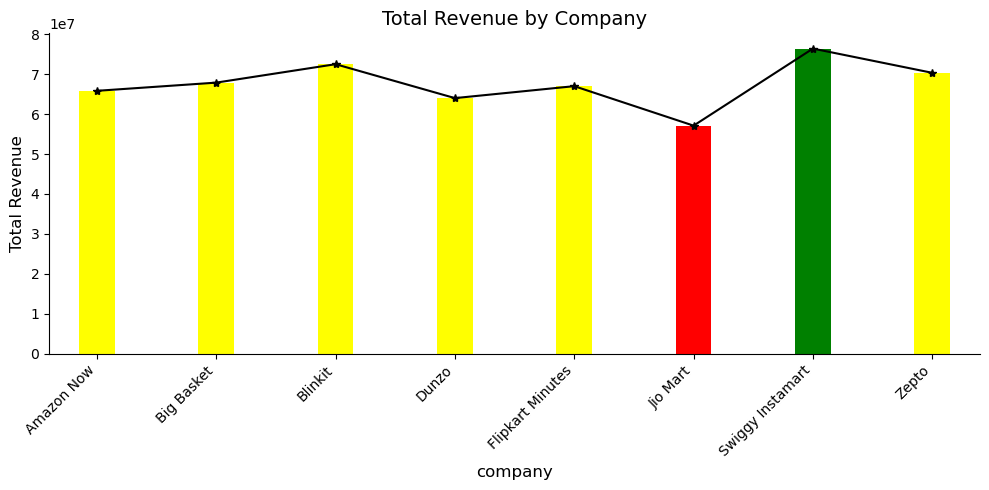

In [8]:
# Bar and line chart
plt.figure(figsize =(10,5))


# Find max and min value
max_value = company_revenue.max()
min_value =company_revenue.min()

# setting colours
colors = [ 'green'if val ==max_value else 
            'red' if val == min_value else
           'yellow'
               for val in company_revenue]



# Draw a bar chart

company_revenue.plot(kind = 'bar', color =colors , width =0.3  )
company_revenue.plot(kind = 'line', color = 'black' , marker = '*')

# Title & x,y label
plt.xlabel ( "company", fontsize = 12)
plt.ylabel ( "Total Revenue", fontsize = 12)
plt.title("Total Revenue by Company" , fontsize = 14)
plt.xticks(rotation=45, ha='right' )


# Removing the top and the right border
ax = plt.gca ()  # gca = get current axes
ax.spines['top'].set_visible(False)

ax.spines['right'].set_visible(False)

plt.tight_layout()


plt.show()

### Q2) Which platform has the highest average order value (AOV) ?

In [9]:
# Group data - average order value of caomany (mean)

AOV = df.groupby("Company")["Order_Value"].mean()

AOV.sort_values()

Company
Jio Mart            482.914592
Dunzo               540.317053
Amazon Now          557.510429
Flipkart Minutes    563.176472
Big Basket          575.065542
Zepto               593.258314
Blinkit             609.819198
Swiggy Instamart    644.927250
Name: Order_Value, dtype: float64

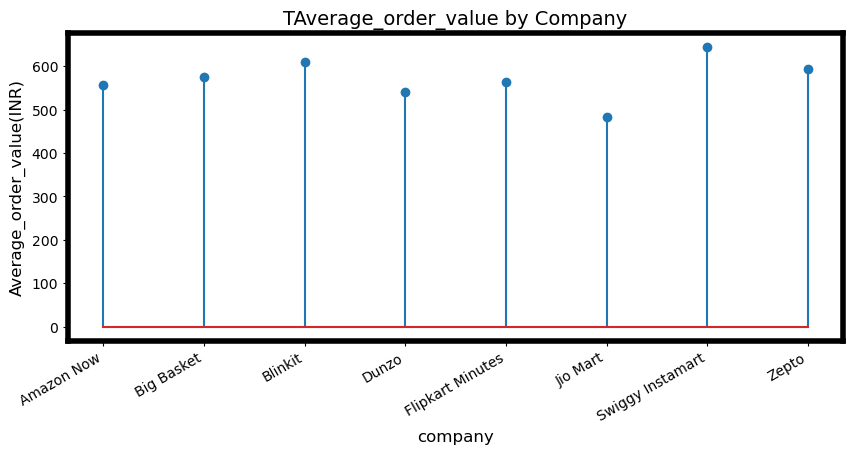

In [10]:
# Stem chart
plt.figure(figsize= (10,4))

plt.stem(AOV.index, AOV.values )  # inside the bracket it is x and y values

# Title & x,y label
plt.xlabel ( "company", fontsize = 12)
plt.ylabel ( "Average_order_value(INR)", fontsize = 12)
plt.title("TAverage_order_value by Company" , fontsize = 14)
plt.xticks(rotation=30, ha='right' )

# Highlight all four borders

ax = plt.gca ()  # gca = get current axis


ax.spines['top'].set_linewidth(4)
ax.spines['right'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)
ax.spines['bottom'].set_linewidth(4)

plt.show()

### Q3) How does customer rating vary across platforms?

In [11]:
median = df.groupby('Company')['Customer_Rating'].median()

median

 # mode = ( df.groupby('Company')
 #       ['Customer_Rating']
 #       .agg(pd.Series.mode)
 #        .reset_index() )

#mode

Company
Amazon Now          3.0
Big Basket          3.0
Blinkit             4.0
Dunzo               2.0
Flipkart Minutes    3.0
Jio Mart            3.0
Swiggy Instamart    3.0
Zepto               3.0
Name: Customer_Rating, dtype: float64

In [12]:
# Count of Ratings
grouped_rating = df.groupby(['Company', 'Customer_Rating']).size().unstack(fill_value = 0)

grouped_rating

Customer_Rating,1,2,3,4,5
Company,,,,,
Amazon Now,15977,30351,30866,29697,11192
Big Basket,10143,30339,31020,30908,15637
Blinkit,1060,25553,25561,36708,30005
Dunzo,29818,36280,25377,25818,1170
Flipkart Minutes,12549,30786,31225,30985,13420
Jio Mart,18513,30515,31083,30089,8067
Swiggy Instamart,5000,30278,31039,30931,21227
Zepto,7618,29763,31367,30559,19258


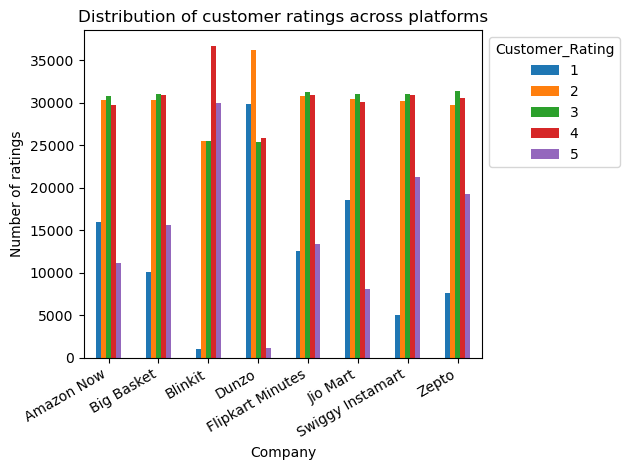

In [13]:
# Bar chart for grouped rating

grouped_rating.plot (kind = 'bar')

plt.xlabel('Company')
plt.ylabel('Number of ratings')
plt.title('Distribution of customer ratings across platforms' )

plt.legend( title = 'Customer_Rating' , bbox_to_anchor = (1,1), loc = 'upper left')

plt.xticks (rotation = 30 , ha = 'right')

plt.tight_layout()
plt.show()

### Q4) Does 'Delivery time' affects the 'delivery partner ratings'?

In [14]:
# Calculate average rating for delivery timings

x = df.groupby('Delivery_Time_Min') [ 'Delivery_Partner_Rating'].mean()

In [ ]:
# Correlation between these two columns

df['Delivery_Time_Min'].corr(df['Delivery_Partner_Rating'])

In [15]:
# creating a graph for "x" would be confusing, hence we will club the Delivery time into 5 Groups, creating a new column

In [16]:
# Creating a new column using cut function

df['Delivery_Time_Bucket'] =pd.cut ( 
                            df['Delivery_Time_Min'],
                            bins = (0,10,20,30,40,50),
                            labels = ('very fast delivery', 'fast delivery', 'normal delivery', 'slow delivery', 'very slow delivery'))

In [17]:
# Calculate average rating for delivery time bucket

bucket_avg = df.groupby('Delivery_Time_Bucket') [ 'Delivery_Partner_Rating'].mean()

C:\Users\a0808\AppData\Local\Temp\ipykernel_14056\4272382732.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_avg = df.groupby('Delivery_Time_Bucket') [ 'Delivery_Partner_Rating'].mean()


In [18]:
bucket_avg

Delivery_Time_Bucket
very fast delivery    3.803231
fast delivery         3.800835
normal delivery       3.798345
slow delivery         3.783646
very slow delivery         NaN
Name: Delivery_Partner_Rating, dtype: float64

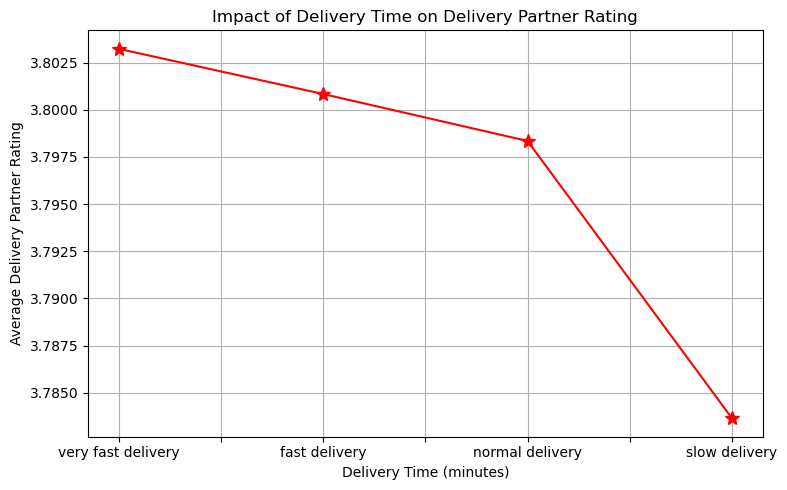

In [19]:
# Line chart 
plt.figure(figsize = (8,5))

bucket_avg.plot (kind = 'line' , marker = '*', markersize = 10 , color= 'red')

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Average Delivery Partner Rating")
plt.title("Impact of Delivery Time on Delivery Partner Rating")
plt.grid(True)

plt.tight_layout()
plt.show()

### Q5) what is the most popular Product Category on swiggy instamart, for the people of age between 30-40, in mumbai?

In [21]:
# Filtering the required dataset

df_PC =  df [(df['Company'] == 'Swiggy Instamart' ) &
            (df['City'] == 'Mumbai') &
            ((df['Customer_Age'] >=30) & (df['Customer_Age'] <40)) 
                ]



In [22]:
# Most popular product category

y = df_PC['Product_Category'].value_counts ()
y

Product_Category
Dairy                  368
Fruits & Vegetables    343
Groceries              341
Household              340
Snacks                 329
Personal Care          305
Beverages              299
Name: count, dtype: int64

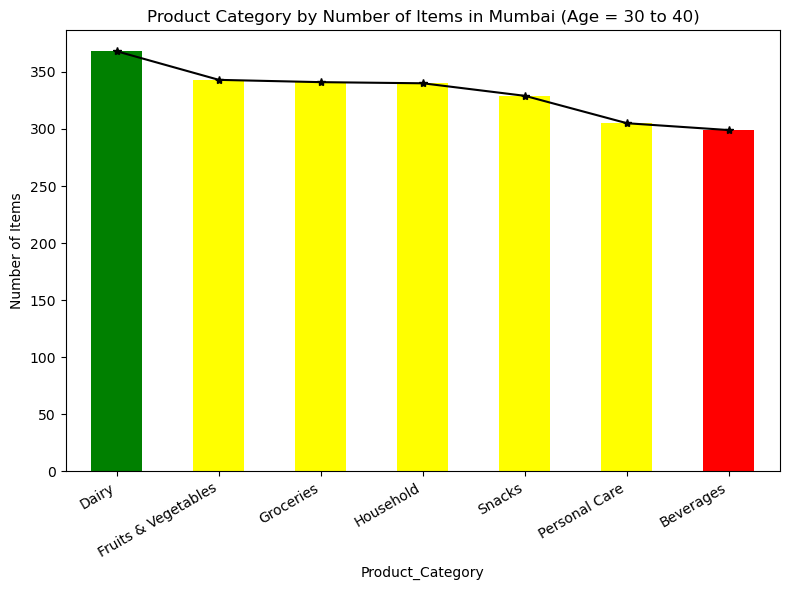

In [23]:
# Bar & Line chart

plt.figure(figsize = (8,6))


plt.xlabel("Product Category")
plt.ylabel("Number of Items")
plt.title("Product Category by Number of Items in Mumbai (Age = 30 to 40)")

max_value = y.max()
min_value =y.min()

# setting colours
colors = [ 'green'if val ==max_value else 
            'red' if val == min_value else
           'yellow'
               for val in y]

y.plot(kind = 'bar', color= colors )
y.plot(kind = 'line', marker = '*', color = 'black') 

plt.xticks(rotation = 30, ha = 'right')


plt.tight_layout()
plt.show()

### Q6) Which cities should these company expand into based on performance?

In [24]:
# Group data and apply aggregate functions

city_perf = df.groupby(['Company', 'City']) . agg(
                                        Total_Orders = ('Order_ID', 'count'),
                                        Avg_Rating = ('Customer_Rating', 'mean'),
                                        Avg_Delivery_Time = ('Delivery_Time_Min', 'mean'),
                                        Total_Revenue = ('Order_Value' , 'sum')
                                          ) .reset_index()

In [25]:
# Filtering out the best cities based on given condition
# Criterias 1) Avg rating >=3.5  
#           2) Avg delivery time <= 15
#           3) Total orders > Median of total orders


best_cities = city_perf [
                        (city_perf ['Avg_Rating'] >= 3.5) &
                        (city_perf ['Avg_Delivery_Time'] <= 15)&
                        (city_perf ['Total_Orders'] > city_perf ['Total_Orders']. median())
                          ]

In [26]:
best_cities

,Company,City,Total_Orders,Avg_Rating,Avg_Delivery_Time,Total_Revenue
24,Blinkit,Amritsar,9932,3.589106,14.199154,6006361
26,Blinkit,Chennai,9876,3.580903,14.135581,5921870
28,Blinkit,Gurgaon,10078,3.579381,14.199345,7374774
32,Blinkit,Kolkata,10004,3.566873,14.142743,6003384
35,Blinkit,Pune,9908,3.583266,14.164110,5930415
85,Zepto,Bengluru,9971,3.598636,9.198977,6041668


In [27]:
best_cities[['Company', 'City']]

,Company,City
24,Blinkit,Amritsar
26,Blinkit,Chennai
28,Blinkit,Gurgaon
32,Blinkit,Kolkata
35,Blinkit,Pune
85,Zepto,Bengluru


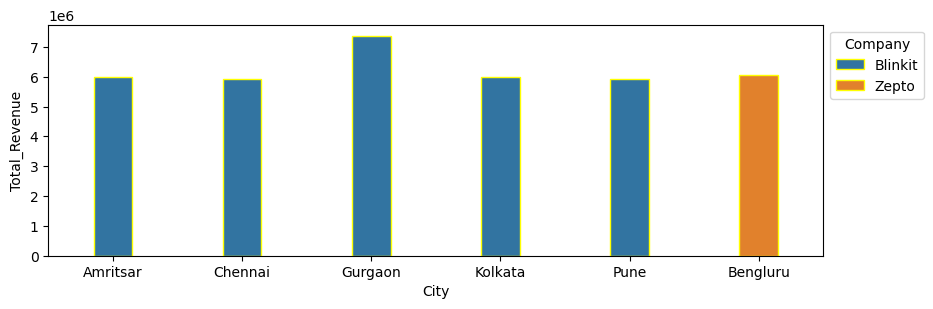

In [28]:
# Bar plot using seaborn library

plt.figure(figsize = (10,3))

sns.barplot( data = best_cities, x= 'City', y='Total_Revenue', hue= 'Company', edgecolor = 'yellow' , width= 0.3 )

plt.legend( title = 'Company', bbox_to_anchor = (1,1) )

plt.show()

### Q7) Are discounts increasing the order value or just reducing the revenue?

In [29]:
#Count the number of orders with & without Discount  

df['Discount_Applied'].value_counts()

Discount_Applied
0    567906
1    379846
Name: count, dtype: int64

In [30]:
# 0 = "False" i.e NO Discount applied

# 1 = "True" i.e Discount applied

In [31]:
# Group data - calculate average order value

dis_order_value = df.groupby('Discount_Applied')['Order_Value'].mean()


# Group data- Calculate the sum of items count

dis_items_count = df.groupby('Discount_Applied')['Items_Count'].sum()

In [33]:
# Giving Unique color to both bar graph

x = df['Discount_Applied'].unique()

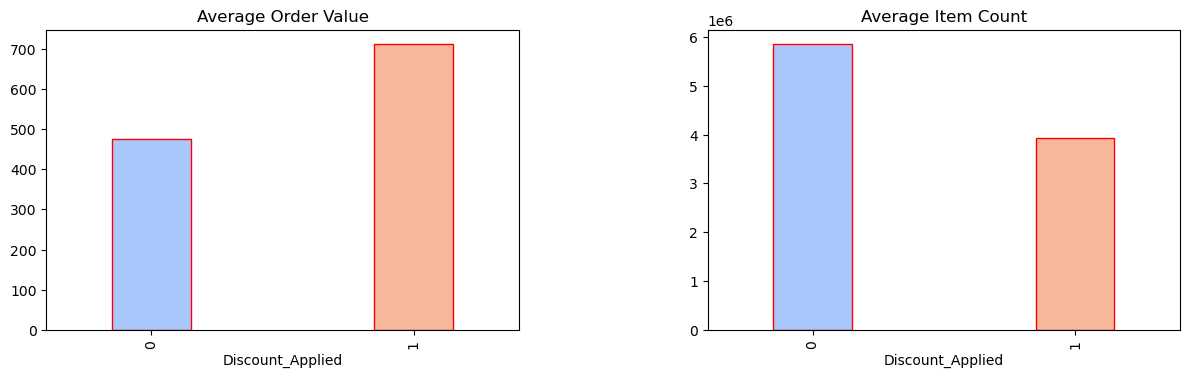

In [37]:
# Seaborn used to plot the graph

plt.figure(figsize = (12,8))

#Use gradient color
color = sns.color_palette("coolwarm", len(x))


plt.subplot(2,2, 1)
dis_order_value.plot(kind = 'bar', width = 0.3, edgecolor = 'red' , color = color )
plt.title("Average Order Value")

plt.subplot(2,2,2)
dis_items_count.plot(kind = 'bar', width = 0.3, edgecolor = 'r' , color = color )
plt.title("Average Item Count")


plt.tight_layout()     #== Automato=ic adjust the spacing

plt.subplots_adjust( wspace= 0.4, hspace =0.5 )

#    plt.tight_layout()     == Automato=ic adjust the spacing


plt.show()

### Q8) which company has the best operational efficiency (Delivery Time vs Order Volume)?

In [38]:
# Group data and apply aggregate functions

company_efficiency = df.groupby('Company').agg(
                           Total_Orders = ('Order_ID', 'count' ) ,
                            Avg_Delivery_Time = ('Delivery_Time_Min' , 'mean' )
                            ).reset_index()

#### Normalize the value for fair comparision as order value is very high as compared to delivery time by Scaling Process

In [39]:
from sklearn.preprocessing import MinMaxScaler

In [40]:
# Scaling both the column to the same range (0 to 1) so that they can be fairly  compared and combined.

scaler = MinMaxScaler()  # create a scaling object

company_efficiency [['Total_Orders_Scaled' , 'Avg_Delivery_Time_Scaled']] = scaler.fit_transform (
                                      company_efficiency [['Total_Orders' , 'Avg_Delivery_Time' ]]          
                                            
                                            )

In [41]:
# Calculating Efficiency score (hiher orders, lower time)

company_efficiency['Efficiency Score'] = company_efficiency['Total_Orders_Scaled'] - company_efficiency['Avg_Delivery_Time_Scaled']

In [42]:
# Sort by best efficiency

Eff_Sort = company_efficiency.sort_values('Efficiency Score', ascending = False)

Eff_Sort

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency Score
7,Zepto,118565,9.644313,0.564270,0.000000,0.564270
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580,0.446420
3,Dunzo,118463,14.177060,0.453159,0.339051,0.114108
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845,-0.014614
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
5,Jio Mart,118267,23.013224,0.239651,1.000000,-0.760349


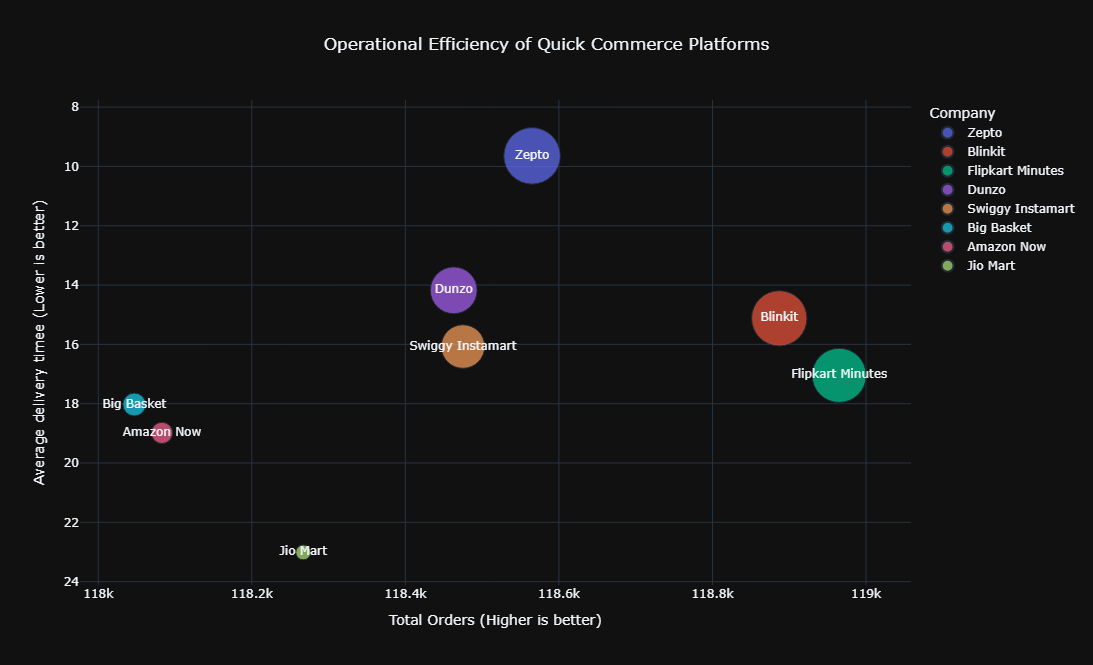

In [44]:
# Use plotly library - Scatter Bubble plot

import plotly.express as px

# Create positive bubble size
min_eff = Eff_Sort['Efficiency Score'].min()
Eff_Sort['Bubble_Size'] = Eff_Sort['Efficiency Score'] - min_eff + 0.1


# PLOT
fig = px.scatter(Eff_Sort, x = 'Total_Orders' ,  y = 'Avg_Delivery_Time' , size ='Bubble_Size', color = 'Company', text = 'Company' ,
                title = 'Operational Efficiency of Quick Commerce Platforms',
                hover_data = {'Total_Orders' : True , 'Avg_Delivery_Time': ':.2f' , 'Efficiency Score' : ':.3f'  },
                size_max = 40)


# Improve chart
fig.update_layout (
                    height = 650,
                    width = 1100,
                    xaxis_title = 'Total Orders (Higher is better)',
                    yaxis_title = 'Average delivery timee (Lower is better)',
                    title_x = 0.5,
                    template = "plotly_dark"
                    )
# Make labels cleaner
fig.update_traces(textposition = 'middle center')

# Reverse Y-axis so best performance appers higher
fig.update_yaxes(autorange = 'reversed' )

fig.show()


### Mini Dashboard ( KPI Card & KPI Charts)

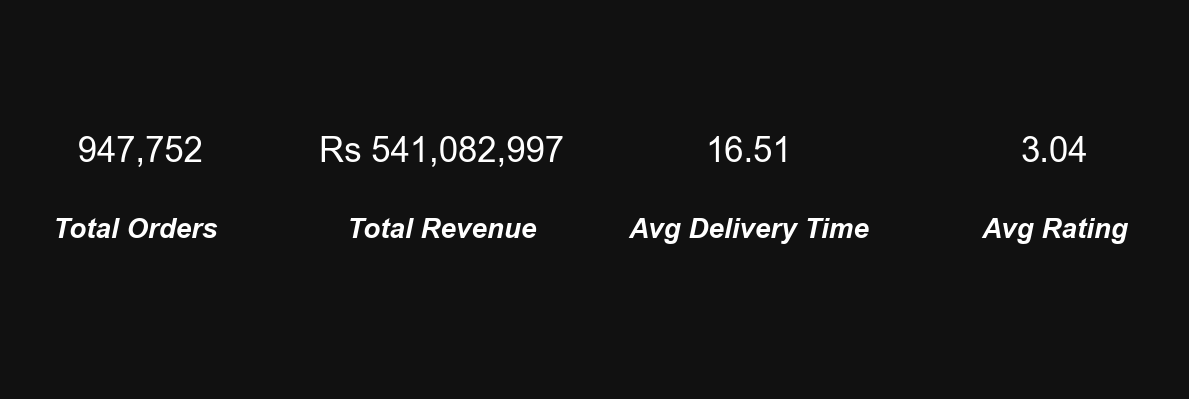

In [45]:
# Create Dashboard layout
#--------------------

fig = plt.figure(figsize = (12,12))

sns.set_style("darkgrid")  # whitegrid for white theme

fig.patch.set_facecolor('#111111')  ## Make the overall figure background dark (nothing needed for whitegrid)
 
#-----------------
# KPI calculation
#------------------
total_order = df['Order_ID'].count()
total_revenue = df['Order_Value'].sum()
avg_delivery_time = df['Delivery_Time_Min'].mean()
avg_rating = df['Customer_Rating'].mean()


# ------------------
# KPI Cards
# ------------------
plt.subplot2grid((3,4) , (0,0) )
plt.axis('off')
plt.text(0.5, 0.6, f"{total_order: ,}" , fontsize = 25, ha = 'center', color = 'white' )
plt.text(0.5, 0.4, "Total Orders", fontsize = 20 , ha = 'center', fontstyle = 'italic', fontweight = 'bold' , color = 'white' )

plt.subplot2grid((3,4) , (0,1) )
plt.axis('off')
plt.text(0.5, 0.6, f"Rs{total_revenue: ,}" , fontsize = 25, ha = 'center' , color = 'white')
plt.text(0.5, 0.4, "Total Revenue", fontsize = 20 , ha = 'center', fontstyle = 'italic', fontweight = 'bold' , color = 'white' )

plt.subplot2grid((3,4) , (0,2) )
plt.axis('off')
plt.text(0.5, 0.6, f"{avg_delivery_time:.2f}" , fontsize = 25, ha = 'center', color = 'white' )
plt.text(0.5, 0.4, "Avg Delivery Time", fontsize = 20 , ha = 'center', fontstyle = 'italic', fontweight = 'bold', color = 'white'  )

plt.subplot2grid((3,4) , (0,3) )
plt.axis('off')
plt.text(0.5, 0.6, f"{avg_rating:.2f}" , fontsize = 25, ha = 'center', color = 'white' )
plt.text(0.5, 0.4, "Avg Rating", fontsize = 20 , ha = 'center', fontstyle = 'italic', fontweight = 'bold' , color = 'white' )





plt.tight_layout()
plt.show()

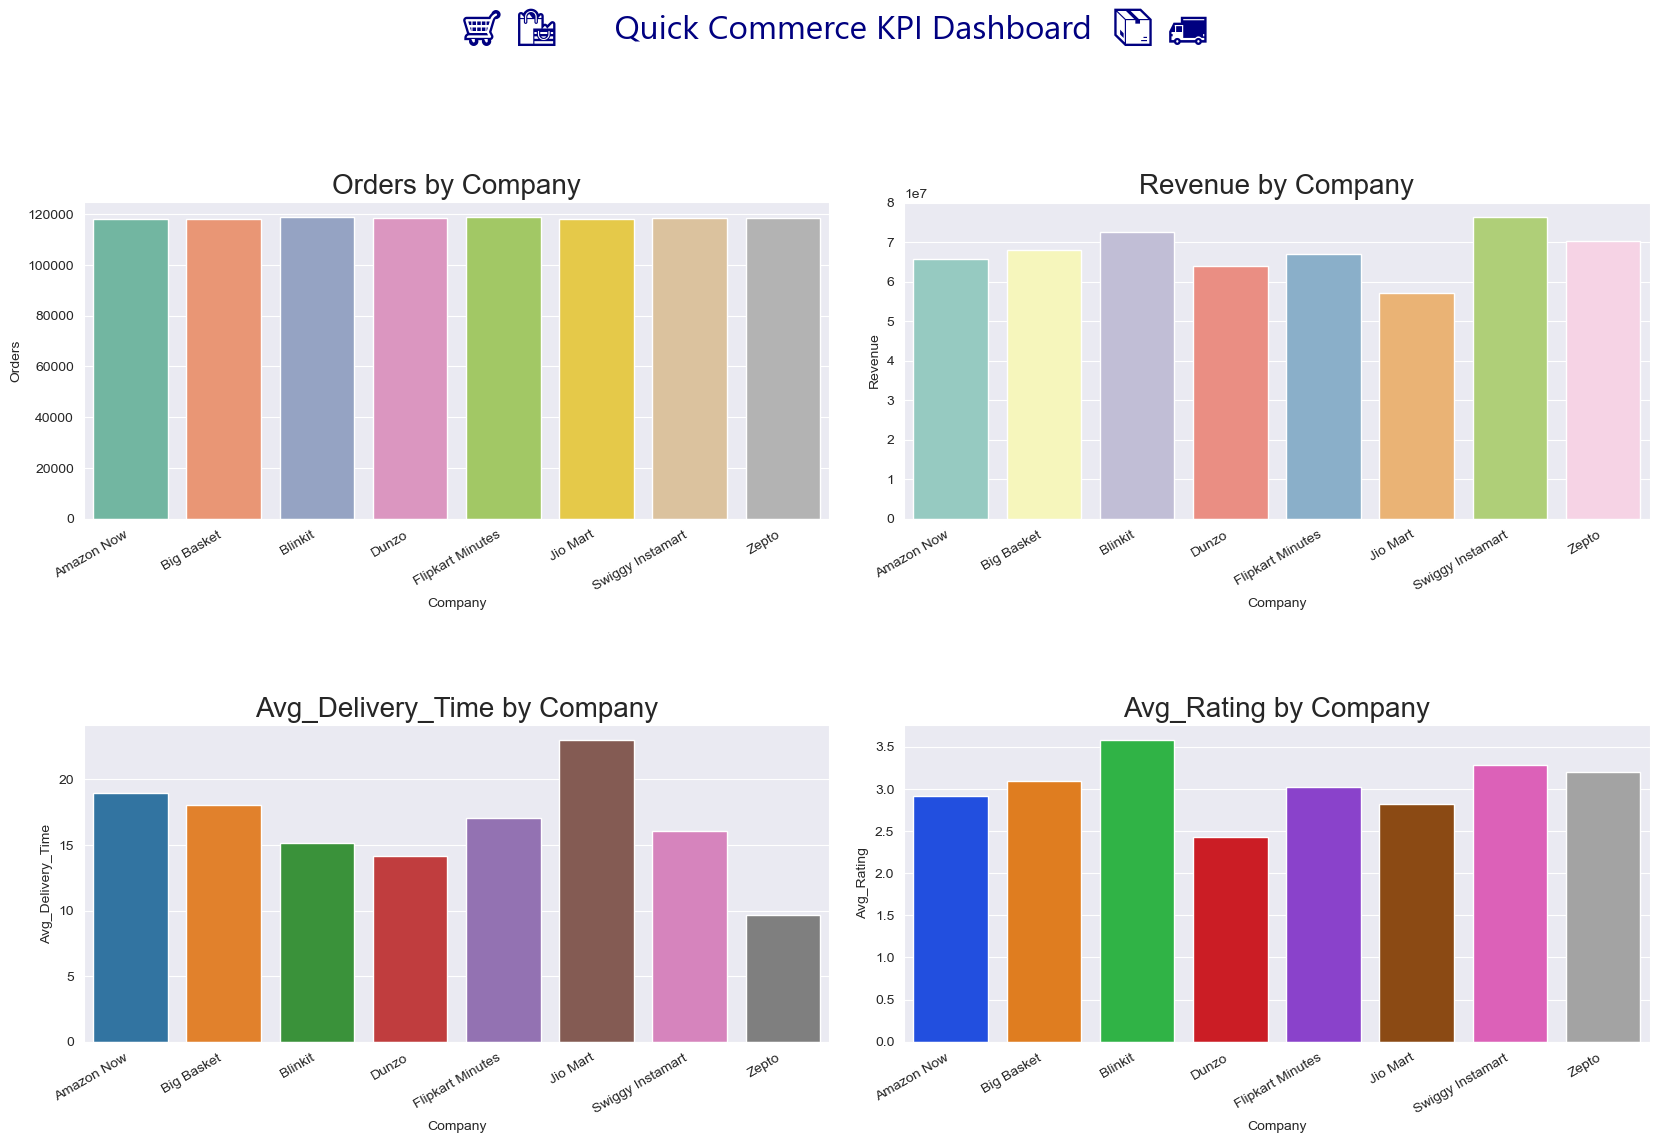

In [46]:
#------------------------
# Company level metrices
# ------------------------

company_metrics = df.groupby('Company').agg (
                            Orders = ('Order_ID', 'count'),
                            Revenue = ('Order_Value' , 'sum' ),
                            Avg_Delivery_Time = ('Delivery_Time_Min', 'mean'),
                            Avg_Rating = ('Customer_Rating' , 'mean')
                                    ).reset_index()



#----------------
# Charts Section

plt.figure(figsize=(18, 12))

# 1) Orders by company

plt.subplot2grid((2,2) , (0,0))
sns.barplot (data = company_metrics, x = 'Company', y = 'Orders', palette = 'Set2', errorbar = None, hue = 'Company', legend = False )
plt.title ( "Orders by Company" , fontsize= 20 )
plt.xticks(rotation = 30, ha = 'right')

# 2) Revenue by company

plt.subplot2grid((2,2) , (0,1))
sns.barplot (data = company_metrics, x = 'Company', y = 'Revenue', palette = 'Set3', errorbar = None, hue = 'Company', legend = False )
plt.title ( "Revenue by Company" , fontsize= 20 )
plt.xticks(rotation = 30, ha = 'right')

# 3) Avg Delivery Time by Company 

plt.subplot2grid((2,2) , (1,0))
sns.barplot (data = company_metrics, x = 'Company', y = 'Avg_Delivery_Time', palette = 'tab10', errorbar = None, hue = 'Company', legend = False )
plt.title ( "Avg_Delivery_Time by Company" , fontsize= 20 )
plt.xticks(rotation = 30, ha = 'right')



# 4) Avg Rating by Company 

plt.subplot2grid((2,2) , (1,1))
sns.barplot (data = company_metrics, x = 'Company', y = 'Avg_Rating', palette = 'bright', errorbar = None, hue = 'Company', legend = False )
plt.title ( "Avg_Rating by Company" , fontsize= 20 )
plt.xticks(rotation = 30, ha = 'right')


# ---------------------
# Dashboard Title
# ---------------------

plt.rcParams ['font.family'] = "Segoe UI Emoji"

plt.suptitle("🛒 🛍️ Quick Commerce KPI Dashboard  📦 🚚 " , fontsize = 24, color ='navy', ha = 'center', fontweight = 'bold' )



plt.subplots_adjust(
    left=0.08,      # Left-side margin
    right=0.95,     # Right-side margin
    bottom=0.12,    # Bottom margin
    top=0.82,       # Space reserved for dashboard title
    wspace=0.1,    # Horizontal space between left and right charts
    hspace=0.65     # Vertical space between top and bottom charts
)

plt.show ()